# 09 — Linear Functions

**Start of a new block: _Equations and Inequalities_.** We finished the *Review* block
(real numbers → algebra → polynomials → roots). Now we use those tools to study real
**functions**, beginning with the simplest and most important one: the **linear
function**.

Mental picture: a linear function is a **straight road on a hill**. For every step you
take forward (change in $x$), you go up or down by the *same* amount (change in $y$).
That constant "steepness" is the **slope**. There are no curves, no surprises — the rate
never changes. This is why linear functions are the first thing every scientist learns:
they are the *building block* that everything else is approximated by.

**Why it matters for AI.** The formula $y = mx + b$ is literally a **single neuron with
no activation**: $m$ is the *weight*, $b$ is the *bias*. **Linear regression** — fitting
the best straight line through data — is the "hello world" of machine learning, and we
will actually do it at the end with `numpy`. Even deep networks are layers of linear
functions glued together with simple bends.

## Quick recall (spaced repetition)
Before the new topic, three warm-ups from earlier sessions. Try them in your head; full
solutions are at the **end of §1**.

1. **(topic 8, sign trap)** Simplify $\sqrt{(x-4)^2}$ for *any* real $x$.
2. **(topic 8)** Evaluate $8^{2/3}$ and $16^{-3/4}$ without a calculator.
3. **(weak spot)** Convert the repeating decimal $0.\overline{27}$ to a fraction.

## What we cover today
1. What a **function** is (domain, range, the vertical-line test).
2. The **linear function** $f(x)=mx+b$: slope and intercept.
3. **Slope** as a constant *rate of change* — and the theorem that this *characterizes*
   linear functions (proved both directions).
4. Forms of a line: **slope-intercept**, **point-slope**; two points give a **unique**
   line (existence + uniqueness, proved).
5. **Increasing / decreasing / constant** (proved from the sign of $m$).
6. **Parallel** and **perpendicular** lines (perpendicular proved with Pythagoras —
   callback to topic 3).
7. Python: plotting lines, average rate of change, and **linear regression** (the AI hook).

## 1. What is a function?

A **function** is a rule that takes an input and gives **exactly one** output.

> **Definition (function).** Let $A$ and $B$ be sets. A **function** $f : A \to B$ is a
> rule that assigns to *each* element $x \in A$ **one and only one** element
> $f(x) \in B$.
> - $A$ is the **domain** (all allowed inputs).
> - $B$ is the **codomain** (where outputs live).
> - The **range** is the set of values actually hit: $\{\, f(x) : x \in A \,\}$.

The key word is *exactly one*. If one input could give two different outputs, it is **not**
a function.

**Notation.** We write $f(x)$ ("f of x") for the output at input $x$. The letter $x$ is
the **independent variable** (we choose it); $y=f(x)$ is the **dependent variable** (it
depends on $x$).

**The vertical-line test (a picture of "exactly one").** Draw the graph of the rule in
the plane (all points $(x, f(x))$). The rule is a function **iff** every vertical line
crosses the graph at **most once**. Why? A vertical line $x=a$ collects all outputs for
the single input $a$. "At most once" means "at most one output" — exactly the function
rule.

ASCII picture:

```
   function (ok)            NOT a function
   y                        y
   |    /                   |   ( )      <- vertical line hits twice
   |   /                    |  /   \
   |  /                     | |     |
   |_/_________ x           |__\___/______ x
```

### Solutions to the recall warm-ups

1. $\sqrt{(x-4)^2} = |x-4|$. **Not** $x-4$. The square root symbol always returns the
   non-negative root, so we must use absolute value. (If $x=1$: $\sqrt{(1-4)^2}=\sqrt 9=3=|1-4|$,
   while $x-4=-3$ — wrong.)
2. $8^{2/3} = (8^{1/3})^2 = 2^2 = 4$. And $16^{-3/4} = \dfrac{1}{16^{3/4}}
   = \dfrac{1}{(16^{1/4})^3} = \dfrac{1}{2^3} = \dfrac18$.
3. Let $x = 0.\overline{27} = 0.272727\ldots$. Multiply by $10^2=100$ (the block has 2
   digits): $100x = 27.2727\ldots$. Subtract: $100x - x = 27$, so $99x = 27$ and
   $x = \dfrac{27}{99} = \dfrac{3}{11}$.

## 2. The linear function

> **Definition (linear function).** A **linear function** is a function of the form
> $$ f(x) = m x + b, \qquad m, b \in \mathbb{R}, $$
> where $m$ and $b$ are fixed real numbers (constants). Its domain is all of
> $\mathbb{R}$.
> - $m$ is the **slope** (the steepness / rate of change).
> - $b$ is the **y-intercept**: $f(0) = m\cdot 0 + b = b$, so the graph meets the
>   $y$-axis at the point $(0,b)$.

The graph of $y = mx + b$ is a **straight line**. (We will *prove* the deep fact —
constant slope — below; that a straight line is what you get is its geometric meaning.)

**Slope = rise over run.** Take two different points on the line, $(x_1,y_1)$ and
$(x_2,y_2)$ with $x_1 \ne x_2$. The slope is
$$ m = \frac{\text{rise}}{\text{run}} = \frac{y_2 - y_1}{x_2 - x_1}
     = \frac{\Delta y}{\Delta x}. $$
The symbol $\Delta$ (Greek "delta") means "change in". So slope is *change in output
per unit change in input*.

**Special cases.**
- $m = 0$: $f(x) = b$ is a **constant function**; the graph is a flat horizontal line.
- $b = 0$: $f(x) = mx$ passes through the origin; output is **proportional** to input.
- A **vertical** line $x = a$ is **not** a function (it fails the vertical-line test) and
  has *no slope* (run $=0$, division by zero).

### Average rate of change

> **Definition (average rate of change, ARC).** For a function $f$ and two inputs
> $x_1 \ne x_2$, the **average rate of change** of $f$ from $x_1$ to $x_2$ is
> $$ \mathrm{ARC} = \frac{f(x_2) - f(x_1)}{x_2 - x_1}. $$

This is the slope of the straight line joining the two graph points (the **secant
line**). For a general curve the ARC changes depending on which two points you pick. The
magic of a linear function is that **it never changes** — that is the next theorem.

(Forward hook: when $x_2 \to x_1$, the ARC becomes the *derivative* — the heart of
calculus. We already met its cousin, the **difference quotient**, in topic 7.)

## 3. Constant rate of change *characterizes* linear functions

This is the central theorem of the topic. It says: "linear" and "constant rate of
change" are **the same idea**.

> **Theorem 1 (constant-slope characterization).** A function $f:\mathbb{R}\to\mathbb{R}$
> is linear (i.e. $f(x)=mx+b$ for some constants $m,b$) **if and only if** its average
> rate of change is the *same number* for every pair of distinct inputs.

**Proof.**

**($\Rightarrow$) Linear implies constant ARC.** Suppose $f(x)=mx+b$. Take any
$x_1\ne x_2$. Then
$$ \frac{f(x_2)-f(x_1)}{x_2-x_1}
 = \frac{(mx_2+b)-(mx_1+b)}{x_2-x_1}
 = \frac{m x_2 - m x_1}{x_2-x_1}
 = \frac{m(x_2-x_1)}{x_2-x_1} = m. $$
The $+b$ cancels and the factor $(x_2-x_1)$ cancels (it is non-zero because
$x_1\ne x_2$). So the ARC equals the constant $m$, no matter which points we chose. $\;\checkmark$

**($\Leftarrow$) Constant ARC implies linear.** Suppose there is a single number $m$ such
that for *all* $x_1 \ne x_2$,
$$ \frac{f(x_2)-f(x_1)}{x_2-x_1} = m. $$
Pick the special anchor $x_1 = 0$ and any $x \ne 0$ for $x_2$. Then
$$ \frac{f(x)-f(0)}{x-0} = m \quad\Longrightarrow\quad f(x)-f(0) = m x
   \quad\Longrightarrow\quad f(x) = m x + f(0). $$
Set $b := f(0)$ (a fixed number). This gives $f(x)=mx+b$ for every $x\ne 0$, and it also
holds at $x=0$ since $m\cdot 0+b = b = f(0)$. Hence $f$ is linear. $\;\blacksquare$

**Why this matters.** It means we can *recognise* a linear relationship in data just by
checking: does $y$ change by the same amount each time $x$ goes up by $1$? If yes, it is a
line, and the constant change **is** the slope.

> **Theorem 2 (slope is well-defined).** For a non-vertical line, the slope computed
> from *any* two distinct points is the same. So the formula $m=\dfrac{\Delta y}{\Delta x}$
> gives one number, not many.

**Proof.** A non-vertical line is exactly the graph of some $f(x)=mx+b$ (that is what
"line" means here). By the ($\Rightarrow$) direction of Theorem 1, *every* pair of
distinct points on it yields the same ratio $m$. So the slope does not depend on the
chosen points. $\;\blacksquare$

(Geometric version: the two right triangles you draw under any two secant pieces are
**similar** — same shape — so their height/base ratios are equal. This is the
similar-triangles picture of "rise over run is constant".)

## 4. Forms of a line, and the two-point theorem

Three ways to write the same line:

| Form | Formula | When to use |
|------|---------|-------------|
| **Slope-intercept** | $y = mx + b$ | you know slope $m$ and intercept $b$ |
| **Point-slope** | $y - y_1 = m(x - x_1)$ | you know slope $m$ and one point $(x_1,y_1)$ |
| **General / standard** | $Ax + By = C$ | tidy integer form; includes vertical lines |

**Point-slope comes straight from the slope formula.** If $(x,y)$ is any other point on
the line through $(x_1,y_1)$ with slope $m$, then $\dfrac{y-y_1}{x-x_1}=m$. Multiply both
sides by $(x-x_1)$:
$$ y - y_1 = m\,(x - x_1). $$

> **Theorem 3 (two points determine a unique line).** Given two points $(x_1,y_1)$ and
> $(x_2,y_2)$ with $x_1 \ne x_2$, there is **exactly one** linear function whose graph
> passes through both.

**Proof.**

*Existence.* Set $m := \dfrac{y_2-y_1}{x_2-x_1}$ (defined because $x_1\ne x_2$) and
$b := y_1 - m x_1$. Let $f(x)=mx+b$. Check both points:
- $f(x_1) = m x_1 + (y_1 - m x_1) = y_1.\;\checkmark$
- $f(x_2) = m x_2 + y_1 - m x_1 = y_1 + m(x_2-x_1)
   = y_1 + \frac{y_2-y_1}{x_2-x_1}(x_2-x_1) = y_1 + (y_2-y_1) = y_2.\;\checkmark$

So at least one such line exists.

*Uniqueness.* Suppose two linear functions $f(x)=mx+b$ and $g(x)=m'x+b'$ both pass
through the two points. Their slopes are forced: by Theorem 2 each slope equals
$\dfrac{y_2-y_1}{x_2-x_1}$, so $m=m'$. Then from $f(x_1)=y_1=g(x_1)$ we get
$m x_1 + b = m x_1 + b'$, hence $b=b'$. So $f=g$. The line is unique. $\;\blacksquare$

## 5. Increasing, decreasing, constant

> **Definition.** A function $f$ is **increasing** if $x_1 < x_2 \Rightarrow f(x_1) <
> f(x_2)$ (graph goes up left-to-right); **decreasing** if $x_1 < x_2 \Rightarrow f(x_1)
> > f(x_2)$ (goes down); **constant** if $f(x_1)=f(x_2)$ always.

> **Theorem 4 (sign of the slope).** For $f(x)=mx+b$:
> - if $m>0$, $f$ is (strictly) **increasing**;
> - if $m<0$, $f$ is (strictly) **decreasing**;
> - if $m=0$, $f$ is **constant**.

**Proof.** Take any $x_1 < x_2$, so $x_2 - x_1 > 0$. From the ($\Rightarrow$) part of
Theorem 1,
$$ f(x_2) - f(x_1) = m\,(x_2 - x_1). $$
The factor $(x_2-x_1)$ is **positive**. So the sign of the left side equals the sign of
$m$:
- $m>0$: product positive $\Rightarrow f(x_2) > f(x_1)$ — increasing.
- $m<0$: product negative $\Rightarrow f(x_2) < f(x_1)$ — decreasing.
- $m=0$: product zero $\Rightarrow f(x_2) = f(x_1)$ — constant.

Here we used the order rule from topic 2: a positive times a positive is positive, and a
negative times a positive is negative. $\;\blacksquare$

## 6. Parallel and perpendicular lines

> **Theorem 5 (parallel lines).** Two distinct non-vertical lines are **parallel** (never
> meet) **iff** they have **equal slopes** $m_1 = m_2$.

**Proof.** Let the lines be $y=m_1x+b_1$ and $y=m_2x+b_2$ with $b_1 \ne b_2$ (distinct).
They meet where $m_1x+b_1 = m_2x+b_2$, i.e. $(m_1-m_2)x = b_2-b_1$.
- If $m_1 = m_2$: the left side is $0$ but the right side $b_2-b_1\ne 0$ — **no solution**,
  so the lines never meet: parallel.
- If $m_1 \ne m_2$: we can solve $x = \dfrac{b_2-b_1}{m_1-m_2}$ — exactly one meeting
  point, so **not** parallel.

So parallel $\iff m_1=m_2$. $\;\blacksquare$

> **Theorem 6 (perpendicular lines).** Two non-vertical lines with slopes $m_1$ and $m_2$
> are **perpendicular** (meet at a right angle) **iff**
> $$ m_1 \, m_2 = -1, \qquad\text{equivalently}\qquad m_2 = -\frac{1}{m_1}. $$

**Proof (using Pythagoras — callback to topic 3).** Slope does not depend on position
(Theorem 2), so slide both lines so they cross at the **origin** $O=(0,0)$. Their
equations become $y=m_1x$ and $y=m_2x$.

Walk one unit right to $x=1$ on each line. We land on
$$ P = (1,\,m_1) \quad\text{on line 1}, \qquad Q = (1,\,m_2) \quad\text{on line 2}. $$
The angle at $O$ in triangle $OPQ$ is a right angle **iff** the triangle satisfies
Pythagoras: $|OP|^2 + |OQ|^2 = |PQ|^2$. Compute the squared lengths with the distance
formula (topic 3):
$$ |OP|^2 = 1 + m_1^2,\qquad |OQ|^2 = 1 + m_2^2,\qquad
   |PQ|^2 = (1-1)^2 + (m_1-m_2)^2 = (m_1-m_2)^2. $$
Right angle at $O$:
$$ (1+m_1^2) + (1+m_2^2) = (m_1-m_2)^2. $$
Expand the right side: $(m_1-m_2)^2 = m_1^2 - 2m_1m_2 + m_2^2$. Substitute:
$$ 2 + m_1^2 + m_2^2 = m_1^2 - 2 m_1 m_2 + m_2^2. $$
Cancel $m_1^2+m_2^2$ from both sides:
$$ 2 = -2 m_1 m_2 \quad\Longrightarrow\quad m_1 m_2 = -1. $$
Every step is reversible, so perpendicular $\iff m_1 m_2 = -1$. $\;\blacksquare$

(Geometric reading: perpendicular slopes are **negative reciprocals**. If one road climbs
at $+2$, the road at a right angle to it falls at $-\tfrac12$.)

## 7. Worked examples

**Example A — equation from two points.** Find the line through $(1,2)$ and $(3,8)$.
$$ m = \frac{8-2}{3-1} = \frac{6}{2} = 3. $$
Point-slope with $(1,2)$: $y - 2 = 3(x-1) = 3x - 3$, so $y = 3x - 1$. Intercept $b=-1$.
Check: $f(3)=3\cdot3-1=8.\;\checkmark$

**Example B — intercepts.** For $y = 3x - 1$:
- $y$-intercept: set $x=0 \Rightarrow y=-1$, point $(0,-1)$.
- $x$-intercept (the *root* / zero): set $y=0 \Rightarrow 3x-1=0 \Rightarrow x=\tfrac13$,
  point $(\tfrac13,0)$.

**Example C — parallel & perpendicular through a point.** Lines through $(0,5)$:
- *Parallel* to $y=3x-1$: same slope $3 \Rightarrow y = 3x + 5$.
- *Perpendicular* to $y=3x-1$: slope $-\tfrac13 \Rightarrow y = -\tfrac13 x + 5$.

**Example D — a word problem (constant rate).** A taxi charges a \$3.00 base plus \$2.50
per mile. Cost after $x$ miles: $C(x) = 2.5x + 3$. Slope $=2.5$ (\$/mile, the rate),
intercept $=3$ (the fixed start cost). Cost of 10 miles: $C(10)=2.5\cdot10+3=\$28$.

Let's verify all of this with Python.

In [1]:
# Setup. We use numpy for arrays/number-crunching, sympy for exact algebra,
# and matplotlib for plots.
import numpy as np                 # numerical arrays and math
import sympy as sp                 # symbolic (exact) algebra
import matplotlib.pyplot as plt    # plotting

def arc(f, x1, x2):
    # Average rate of change of f from x1 to x2 (the secant slope).
    return (f(x2) - f(x1)) / (x2 - x1)   # the (f(x2)-f(x1))/(x2-x1) formula

# A linear function f(x) = 3x - 1
f = lambda x: 3*x - 1

# Theorem 1: the ARC is the SAME (=3) for every pair of points we try.
pairs = [(0, 1), (1, 3), (-2, 5), (10, 100)]
for (a, b) in pairs:
    print(f"ARC of f from {a} to {b} = {arc(f, a, b)}")   # should always be 3.0

ARC of f from 0 to 1 = 3.0
ARC of f from 1 to 3 = 3.0
ARC of f from -2 to 5 = 3.0
ARC of f from 10 to 100 = 3.0


In [2]:
# A NON-linear function to contrast: g(x) = x**2 has a CHANGING rate of change.
g = lambda x: x**2
for (a, b) in pairs:
    print(f"ARC of g(x)=x^2 from {a} to {b} = {arc(g, a, b)}")   # all different!

ARC of g(x)=x^2 from 0 to 1 = 1.0
ARC of g(x)=x^2 from 1 to 3 = 4.0
ARC of g(x)=x^2 from -2 to 5 = 3.0
ARC of g(x)=x^2 from 10 to 100 = 110.0


In [3]:
# Example A, done symbolically with sympy: line through (1,2) and (3,8).
x = sp.symbols('x')                       # declare a symbol x for exact algebra
x1, y1, x2, y2 = 1, 2, 3, 8
m = sp.Rational(y2 - y1, x2 - x1)         # exact slope as a fraction (6/2 = 3)
b = y1 - m*x1                             # intercept from b = y1 - m*x1
line = m*x + b                            # the function m*x + b
print("slope m =", m)
print("intercept b =", b)
print("line y =", line)
print("check f(3) =", line.subs(x, 3))    # subs() plugs x=3 into the expression -> 8

slope m = 3
intercept b = -1
line y = 3*x - 1
check f(3) = 8


In [4]:
# Intercepts of y = 3x - 1 with sympy.solve (solves an equation == 0).
expr = 3*x - 1
x_int = sp.solve(sp.Eq(expr, 0), x)       # solve 3x-1 = 0 for x  -> the x-intercept
y_int = expr.subs(x, 0)                    # plug x=0             -> the y-intercept
print("x-intercept:", x_int)               # [1/3]
print("y-intercept:", y_int)               # -1

x-intercept: [1/3]
y-intercept: -1


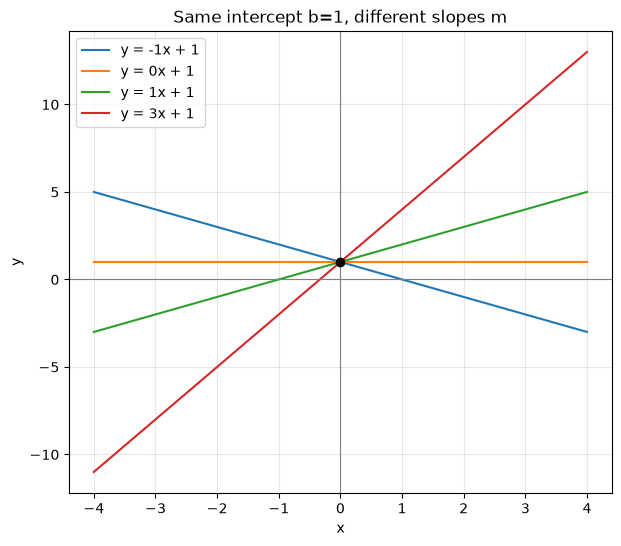

In [5]:
# Plot a family of lines to SEE slope and intercept.
xs = np.linspace(-4, 4, 200)               # 200 evenly spaced x-values from -4 to 4

plt.figure(figsize=(7, 6))
for m_ in (-1, 0, 1, 3):                    # try several slopes, same intercept b=1
    plt.plot(xs, m_*xs + 1, label=f"y = {m_}x + 1")   # plot the line m_*x + 1
plt.axhline(0, color="gray", lw=0.8)        # draw the x-axis
plt.axvline(0, color="gray", lw=0.8)        # draw the y-axis
plt.scatter([0], [1], color="black", zorder=5)        # the shared y-intercept (0,1)
plt.title("Same intercept b=1, different slopes m")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

m1 * m2 = -1


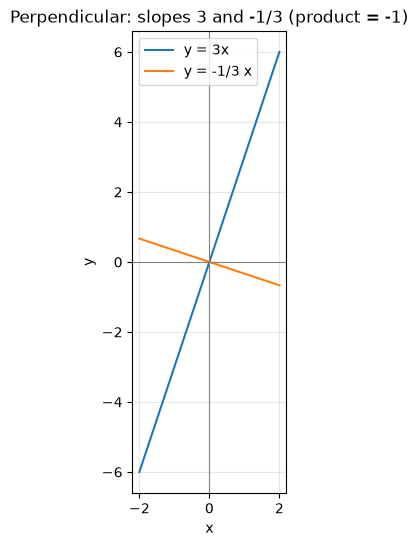

In [6]:
# Theorem 6 check: y = 3x and y = -1/3 x should meet at a RIGHT angle.
m1, m2 = 3, sp.Rational(-1, 3)
print("m1 * m2 =", m1*m2)                   # -1  ->  perpendicular

# Picture with EQUAL axis scaling (so a right angle really looks like 90 degrees).
xs = np.linspace(-2, 2, 100)
plt.figure(figsize=(6, 6))
plt.plot(xs, 3*xs,        label="y = 3x")
plt.plot(xs, -1/3*xs,     label="y = -1/3 x")
plt.axhline(0, color="gray", lw=0.8); plt.axvline(0, color="gray", lw=0.8)
plt.gca().set_aspect("equal")               # equal scale on both axes -> true angles
plt.title("Perpendicular: slopes 3 and -1/3 (product = -1)")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## 8. The AI hook — linear regression (fitting the best line)

Real data never lands *exactly* on a line. **Linear regression** finds the line
$y = mx + b$ that is **closest** to the data — it minimizes the total squared vertical
error
$$ E(m,b) = \sum_{i=1}^{n} \bigl(y_i - (m x_i + b)\bigr)^2 . $$
This is the first real machine-learning model: $m$ is the **weight**, $b$ is the
**bias**, and "training" means choosing $m,b$ to make $E$ as small as possible. Below we
generate noisy points around a known line and let `numpy` recover the slope and
intercept.

true line:      y = 2.0x + -1.0
recovered line: y = 2.046x + -1.323


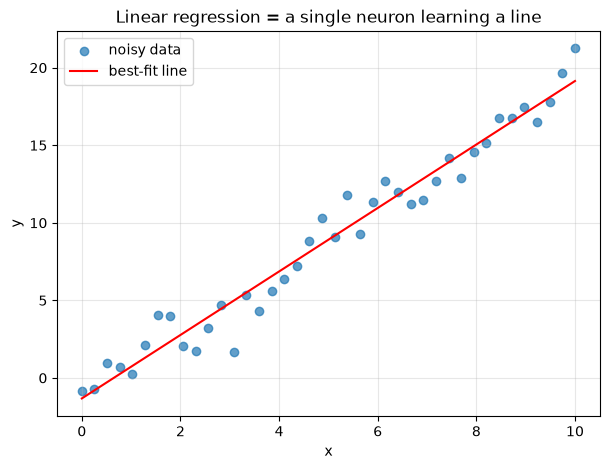

In [7]:
# Linear regression demo: recover a line from noisy data.
rng = np.random.default_rng(0)             # random generator with a fixed seed (repeatable)
true_m, true_b = 2.0, -1.0                  # the secret line we will try to recover
X = np.linspace(0, 10, 40)                  # 40 input points
noise = rng.normal(0, 1.5, size=X.size)     # random Gaussian noise, std-dev 1.5
Y = true_m*X + true_b + noise               # data = true line + noise

# np.polyfit(X, Y, 1) fits a degree-1 polynomial (a line) by least squares.
m_hat, b_hat = np.polyfit(X, Y, 1)          # returns [slope, intercept]
print(f"true line:      y = {true_m}x + {true_b}")
print(f"recovered line: y = {m_hat:.3f}x + {b_hat:.3f}")

plt.figure(figsize=(7, 5))
plt.scatter(X, Y, label="noisy data", alpha=0.7)          # the data points
plt.plot(X, m_hat*X + b_hat, color="red", label="best-fit line")   # fitted line
plt.title("Linear regression = a single neuron learning a line")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Same fit BY HAND with the closed-form least-squares formulas, to demystify polyfit:
#   m = Cov(x,y) / Var(x),   b = mean(y) - m*mean(x).
xbar, ybar = X.mean(), Y.mean()             # means of x and y
m_manual = np.sum((X - xbar)*(Y - ybar)) / np.sum((X - xbar)**2)   # covariance / variance
b_manual = ybar - m_manual*xbar             # forces the line through the mean point
print(f"by hand:  y = {m_manual:.3f}x + {b_manual:.3f}")
print(f"polyfit:  y = {m_hat:.3f}x + {b_hat:.3f}")   # the two should match

by hand:  y = 2.046x + -1.323
polyfit:  y = 2.046x + -1.323


## 9. Exercises (20) — fill these in yourself

Work top to bottom: easy → hard, ending in proofs. Try each **before** checking anything.
Use the empty cell under each group for code, or write proofs as text.

**A. Slope & evaluation**
1. Find the slope of the line through $(2,5)$ and $(6,13)$.
2. For $f(x) = -4x + 7$, compute $f(0)$, $f(3)$, and the $y$-intercept.
3. Find the average rate of change of $f(x)=-4x+7$ from $x=1$ to $x=5$. What do you
   notice, and why (which theorem)?
4. Does $f(x) = 5$ count as a linear function? What is its slope? Is it increasing,
   decreasing, or constant?

In [9]:
# your work for 1–4


**B. Building equations of lines**
5. Write $y = 2x - 3$ in the form $Ax + By = C$ with integer $A,B,C$.
6. Find the equation (slope-intercept) of the line through $(-1, 4)$ with slope $-2$.
7. Find the equation of the line through the two points $(0, -2)$ and $(4, 6)$.
8. Find both intercepts of $3x - 4y = 12$ and sketch the line by hand.

In [10]:
# your work for 5–8


**C. Parallel & perpendicular**
9. Line $L: y = \tfrac12 x + 1$. Write a line **parallel** to $L$ through $(2, -3)$.
10. For the same $L$, write a line **perpendicular** to $L$ through $(2,-3)$.
11. Are $y = 3x + 1$ and $2x - 6y = 5$ parallel, perpendicular, or neither? (Find each
    slope first.)
12. Find $k$ so that the line through $(1,2)$ and $(4,k)$ is perpendicular to $y=-x+9$.

In [11]:
# your work for 9–12


**D. Modeling & reading lines**
13. A gym charges \$50 to join plus \$30 per month. Write the cost $C(t)$ after $t$
    months. What are the slope and intercept *in words*?
14. Water drains from a tank: at $t=0$ min there are $200$ L; at $t=8$ min there are
    $40$ L, draining at a constant rate. Write $V(t)$. When is the tank empty?
15. A line has $x$-intercept $5$ and $y$-intercept $-2$. Find its slope and equation.
16. Two points of a linear $f$ are $f(2)=7$ and $f(5)=1$. Find $f(x)$ and $f(0)$.

In [12]:
# your work for 13–16


**E. Proofs (write carefully, like a scientist)**
17. **Prove** that if $f(x)=mx+b$ with $m\ne 0$, then $f$ has exactly one $x$-intercept,
    and find it.
18. **Prove** Theorem 4 for the decreasing case from scratch: if $m<0$ and $x_1<x_2$,
    then $f(x_1) > f(x_2)$. State clearly which order rule you use.
19. **Prove** the **midpoint** of two points on the line $y=mx+b$ also lies on the line.
    (Take $P=(x_1, mx_1+b)$ and $Q=(x_2, mx_2+b)$; show the midpoint satisfies $y=mx+b$.)
20. **Prove** Theorem 6 (perpendicular $\iff m_1m_2=-1$) in your *own* words, filling in
    every algebra step of the Pythagoras argument. Then explain why the proof needs both
    lines to be **non-vertical**.

In [13]:
# your proofs / work for 17–20 (use markdown for the written proofs)


## 10. Running this notebook with `uv`

This project is managed by **`uv`** (a fast Python package manager). From the project
root (`C:\dev\math`):

```bash
uv sync                 # install the locked dependencies (numpy, sympy, matplotlib, jupyterlab)
uv run jupyter lab      # launch Jupyter Lab, then open notebooks/09-linear-functions.ipynb
```

If you ever add a new library:

```bash
uv add scikit-learn     # example: adds the dependency and updates the lock file
```

To re-run everything top-to-bottom from the command line (a good self-test):

```bash
uv run jupyter nbconvert --to notebook --execute --inplace notebooks/09-linear-functions.ipynb
```

**Next topic:** *Equations and Inequalities ▸ 2. Quadratic Equations* — where the graph
finally bends.